# 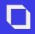 IONCOR Oy Scrap Value Forecasting Dashboard (Random Forest Regressor,XGBoost, ARIMA, LSTM, Prophet)

## 📦 Import, Load libraries and packages

In [3]:
import pandas as pd
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error 
import warnings
warnings.filterwarnings("ignore")

pn.extension()

## 📁 Uploaded Files and Setup

In [5]:
file_dict = {
     "Cell_1_y7": "Cell_1_y7.XLSX",
    "BDU_Y7": "BDU_Y7.XLSX",
    "BMS_48": "BMS_48.XLSX",
    "Converter_48": "Converter_48.XLSX",
    "Base_Tray_vent_Y7": "Base_Tray_vent_Y7.XLSX",
    "BMU_Y7": "BMU_Y7.XLSX",
    "Cell_48": "Cell_48.XLSX",
    "Cooler_48": "Cooler_48.XLSX",
     "Busbar1_Y7": "Busbar1_Y7.XLSX",
    "Cover_Y7": "Cover_Y7.XLSX",
    "Cell_3_y7": "Cell_3_y7.XLSX",
    "Circuit_board_Sensor_48": "Circuit_board_Sensor_48.XLSX",
     "ZELLBLOCK_RE_Uki": "ZELLBLOCK_RE_Uki.XLSX",
    "ZELLBLOCK_LI_Uki": "ZELLBLOCK_LI_Uki.XLSX",
    "LI_ION_Cell_Uki": "LI_ION_Cell_Uki.XLSX",
    "Prismatic_Cell_Uki": "Prismatic_Cell_Uki.XLSX"
    
}


## ⚙️ Define Files and Preprocessing Function

In [7]:
def preprocess_time_series(file_path):
    df = pd.read_excel(file_path)
    df = df[["Posting Date", "Unit Price"]]
    df = df.groupby("Posting Date").sum().reset_index()
    df = df.sort_values("Posting Date")
    df.dropna(inplace=True)
    return df

## 🧠 XGBoost Prediction

In [9]:
def xgboost_forecast(df):
    # 1. Ensure 'Posting Date' is in datetime format
    df['Posting Date'] = pd.to_datetime(df['Posting Date'])
    
    # 2. Define the reference date (January 1, 2019)
    reference_date = pd.Timestamp('2019-01-01')
    
    # 3. Calculate the number of days passed
    df['Days_Since_2019'] = (df['Posting Date'] - reference_date).dt.days
    
    # 4. Set your input X and target y
    X = df[['Days_Since_2019']]
    y = df['Unit Price']

    # --- Model Training ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = XGBRegressor(n_estimators=200, learning_rate=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # --- Metrics ---
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    # Calculate MAPE and multiply by 100 for percentage
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100 
    
    return y_test.reset_index(drop=True), y_pred, rmse, mape

## 🔁 ARIMA Forecasting

In [11]:
def arima_forecast(df):
    series = df.set_index('Posting Date')['Unit Price']
    model = ARIMA(series, order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=int(len(series)*0.2))
    y_true = series[-len(forecast):]
    
    # --- Metrics ---
    rmse = mean_squared_error(y_true, forecast, squared=False)
    mape = mean_absolute_percentage_error(y_true, forecast) * 100
    
    return y_true, forecast, rmse, mape

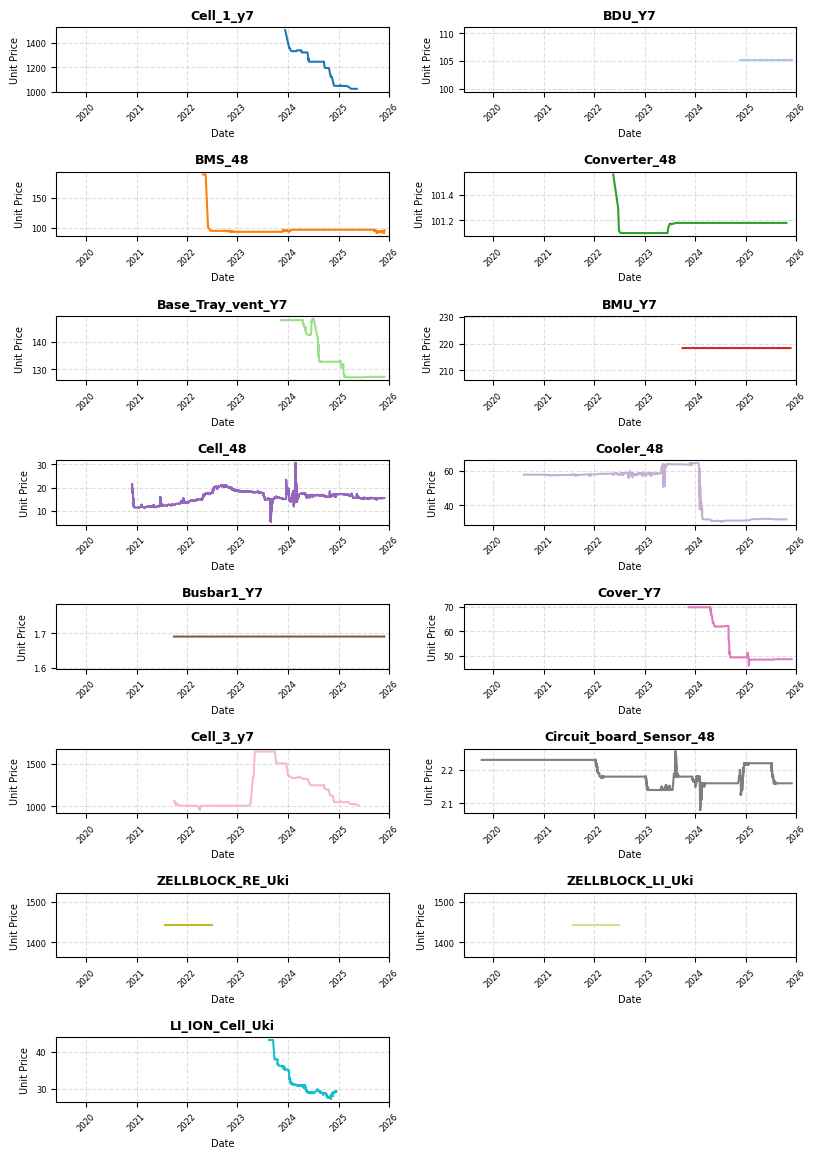

In [12]:
# 📈 Unit Price Analysis
def plot_unit_prices():
    # A4 page dimensions: 8.27 x 11.69 inches (vertical)
    fig, axes = plt.subplots(8, 2, figsize=(8.27, 11.69))
    axes = axes.flatten()
    
    # Generate distinct colors for each product
    colors = cm.tab20(np.linspace(0, 1, len(file_dict)))
    
    # Define the common timeline (2019-2026)
    timeline_start = pd.Timestamp('2019-06-01')
    timeline_end = pd.Timestamp('2026-01-01')
    
    product_list = list(file_dict.items())
    
    # Iterate through each product and plot in the grid
    for idx, (product_name, file_path) in enumerate(product_list):
        try:
            # Load the Excel file
            df = pd.read_excel(file_path)
            
            # Ensure 'Posting Date' is in datetime format
            df['Posting Date'] = pd.to_datetime(df['Posting Date'])
            
            # Sort by date
            df = df.sort_values('Posting Date')
            
            # Compute Unit Price
            df['Unit Price'] = df['Amount in LC'] / df['Quantity']
            
            # Plot on the corresponding subplot
            ax = axes[idx]
            ax.plot(df['Posting Date'], df['Unit Price'], 
                   color=colors[idx], linewidth=1.5)
            ax.set_title(product_name, fontsize=9, fontweight='bold')
            ax.set_xlabel('Date', fontsize=7)
            ax.set_ylabel('Unit Price', fontsize=7)
            ax.tick_params(axis='both', labelsize=6)
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.xaxis.set_major_locator(mdates.YearLocator(1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.tick_params(axis='x', rotation=45)
            
            # Set common timeline for all subplots
            ax.set_xlim(timeline_start, timeline_end)
            
        except Exception as e:
            ax = axes[idx]
            ax.text(0.5, 0.5, f"Error loading\n{product_name}", 
                   ha='center', va='center', fontsize=8)
            ax.set_title(product_name, fontsize=9, fontweight='bold')
            ax.set_xlim(timeline_start, timeline_end)
    
    # Hide the last empty subplot (17 products + 1 empty = 18 total)
    axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('Unit_Prices_Grid.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the plotting function
plot_unit_prices()

## 📊 Plotting function

In [14]:
def create_plot(y_true, y_pred, model_name):
    plt.figure(figsize=(6,3))
    plt.plot(y_true.values, label='Actual')
    plt.plot(y_pred, label='Forecast')
    plt.title(f'{model_name} Forecast')
    plt.xlabel("Time")
    plt.ylabel("Scrap Value")
    plt.legend()
    return pn.pane.Matplotlib(plt.gcf(), tight=True)

## 🤖 Interactive Elements

In [16]:
component_selector = pn.widgets.Select(name='Select Component', options=list(file_dict.keys()))
xgb_plot_pane = pn.pane.Matplotlib()
arima_plot_pane = pn.pane.Matplotlib()
metrics_pane = pn.pane.Markdown()

## 🔁 Update function

Watcher(inst=Select(options=['Cell_1_y7', ...], value='Cell_1_y7'), cls=<class 'panel.widgets.select.Select'>, fn=<function update_dashboard at 0x12c4f07c0>, mode='args', onlychanged=True, parameter_names=('value',), what='value', queued=False, precedence=0)

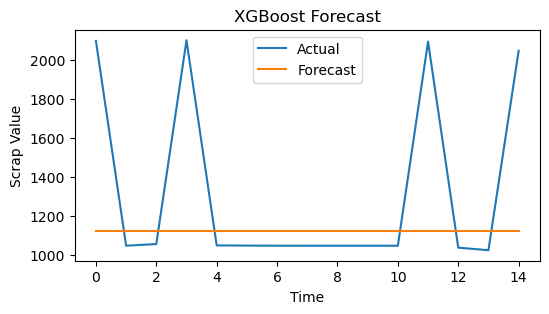

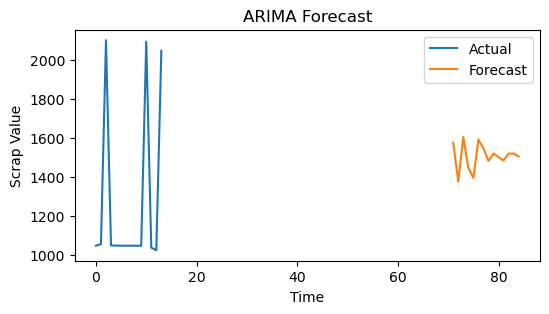

In [18]:
def update_dashboard(event=None):
    file_name = file_dict[component_selector.value]
    df = preprocess_time_series(file_name)
    
    # Unpack the 4 return values (added mape_xgb and mape_arima)
    y_test_xgb, y_pred_xgb, rmse_xgb, mape_xgb = xgboost_forecast(df)
    y_test_arima, y_pred_arima, rmse_arima, mape_arima = arima_forecast(df)

    xgb_plot = create_plot(y_test_xgb, y_pred_xgb, "XGBoost")
    arima_plot = create_plot(y_test_arima, y_pred_arima, "ARIMA")

    xgb_plot_pane.object = xgb_plot.object
    arima_plot_pane.object = arima_plot.object

    # Update the text to include MAPE
    metrics_md = f"""
    ### Forecasting Error Metrics
    - **XGBoost:** RMSE: {rmse_xgb:.2f} | MAPE: {mape_xgb:.2f}%
    - **ARIMA:** RMSE: {rmse_arima:.2f} | MAPE: {mape_arima:.2f}%
    """
    metrics_pane.object = metrics_md

update_dashboard()  # Initial load
component_selector.param.watch(update_dashboard, 'value')

In [19]:
# 📊 Model Evaluation Summary
from IPython.display import display

def generate_metrics_summary():
    results_rmse = []
    results_mape = []
    
    print("Calculating metrics for all components (this may take a moment)...")
    
    for component_name, file_name in file_dict.items():
        try:
            # 1. Preprocess the data using your existing function
            df = preprocess_time_series(file_name)
            
            # 2. Run XGBoost
            # Note: We use _ to ignore the prediction arrays, keeping only metrics
            _, _, rmse_xgb, mape_xgb = xgboost_forecast(df)
            
            # 3. Run ARIMA
            _, _, rmse_arima, mape_arima = arima_forecast(df)
            
            # 4. Store RMSE results
            results_rmse.append({
                'Component': component_name,
                'XGBoost RMSE': round(rmse_xgb, 2),
                'ARIMA RMSE': round(rmse_arima, 2),
                'Best Model': 'XGBoost' if rmse_xgb < rmse_arima else 'ARIMA'
            })
            
            # 5. Store MAPE results
            results_mape.append({
                'Component': component_name,
                'XGBoost MAPE (%)': round(mape_xgb, 2),
                'ARIMA MAPE (%)': round(mape_arima, 2),
                'Best Model': 'XGBoost' if mape_xgb < mape_arima else 'ARIMA'
            })
            
        except Exception as e:
            print(f"Could not calculate for {component_name}: {e}")

    # Convert to DataFrames
    df_rmse = pd.DataFrame(results_rmse)
    df_mape = pd.DataFrame(results_mape)
    
    return df_rmse, df_mape

# Generate and display the tables
df_rmse_results, df_mape_results = generate_metrics_summary()

print("\nTable 1: RMSE Results (Lower is better)")
display(df_rmse_results)

print("\nTable 2: MAPE Results (Lower is better)")
display(df_mape_results)
# 📊 Model Evaluation Summary
from IPython.display import display

def generate_metrics_summary():
    results_rmse = []
    results_mape = []
    
    print("Calculating metrics for all components (this may take a moment)...")
    
    for component_name, file_name in file_dict.items():
        try:
            # 1. Preprocess the data using your existing function
            df = preprocess_time_series(file_name)
            
            # 2. Run XGBoost
            # Note: We use _ to ignore the prediction arrays, keeping only metrics
            _, _, rmse_xgb, mape_xgb = xgboost_forecast(df)
            
            # 3. Run ARIMA
            _, _, rmse_arima, mape_arima = arima_forecast(df)
            
            # 4. Store RMSE results
            results_rmse.append({
                'Component': component_name,
                'XGBoost RMSE': round(rmse_xgb, 2),
                'ARIMA RMSE': round(rmse_arima, 2),
                'Best Model': 'XGBoost' if rmse_xgb < rmse_arima else 'ARIMA'
            })
            
            # 5. Store MAPE results
            results_mape.append({
                'Component': component_name,
                'XGBoost MAPE (%)': round(mape_xgb, 2),
                'ARIMA MAPE (%)': round(mape_arima, 2),
                'Best Model': 'XGBoost' if mape_xgb < mape_arima else 'ARIMA'
            })
            
        except Exception as e:
            print(f"Could not calculate for {component_name}: {e}")

    # Convert to DataFrames
    df_rmse = pd.DataFrame(results_rmse)
    df_mape = pd.DataFrame(results_mape)
    
    return df_rmse, df_mape

# Generate and display the tables
df_rmse_results, df_mape_results = generate_metrics_summary()

print("\nTable 1: RMSE Results (Lower is better)")
display(df_rmse_results)

print("\nTable 2: MAPE Results (Lower is better)")
display(df_mape_results)

Calculating metrics for all components (this may take a moment)...

Table 1: RMSE Results (Lower is better)


,Component,XGBoost RMSE,ARIMA RMSE,Best Model
0,Cell_1_y7,501.20,479.44,ARIMA
1,BDU_Y7,118.68,99.12,ARIMA
2,BMS_48,852.00,857.92,XGBoost
3,Converter_48,59.60,54.71,ARIMA
4,Base_Tray_vent_Y7,104.14,105.63,XGBoost
5,BMU_Y7,322.88,213.40,ARIMA
6,Cell_48,586.49,584.70,ARIMA
7,Cooler_48,106.84,92.55,ARIMA
8,Busbar1_Y7,2.48,2.38,ARIMA
9,Cover_Y7,53.63,57.26,XGBoost



Table 2: MAPE Results (Lower is better)


,Component,XGBoost MAPE (%),ARIMA MAPE (%),Best Model
0,Cell_1_y7,17.78,39.74,XGBoost
1,BDU_Y7,26.91,42.18,XGBoost
2,BMS_48,60.33,48.11,ARIMA
3,Converter_48,11.71,29.29,XGBoost
4,Base_Tray_vent_Y7,40.66,39.07,ARIMA
5,BMU_Y7,118.41,65.93,ARIMA
6,Cell_48,133.86,42.26,ARIMA
7,Cooler_48,206.79,42.55,ARIMA
8,Busbar1_Y7,79.39,52.26,ARIMA
9,Cover_Y7,46.59,37.61,ARIMA


Calculating metrics for all components (this may take a moment)...

Table 1: RMSE Results (Lower is better)


,Component,XGBoost RMSE,ARIMA RMSE,Best Model
0,Cell_1_y7,501.20,479.44,ARIMA
1,BDU_Y7,118.68,99.12,ARIMA
2,BMS_48,852.00,857.92,XGBoost
3,Converter_48,59.60,54.71,ARIMA
4,Base_Tray_vent_Y7,104.14,105.63,XGBoost
5,BMU_Y7,322.88,213.40,ARIMA
6,Cell_48,586.49,584.70,ARIMA
7,Cooler_48,106.84,92.55,ARIMA
8,Busbar1_Y7,2.48,2.38,ARIMA
9,Cover_Y7,53.63,57.26,XGBoost



Table 2: MAPE Results (Lower is better)


,Component,XGBoost MAPE (%),ARIMA MAPE (%),Best Model
0,Cell_1_y7,17.78,39.74,XGBoost
1,BDU_Y7,26.91,42.18,XGBoost
2,BMS_48,60.33,48.11,ARIMA
3,Converter_48,11.71,29.29,XGBoost
4,Base_Tray_vent_Y7,40.66,39.07,ARIMA
5,BMU_Y7,118.41,65.93,ARIMA
6,Cell_48,133.86,42.26,ARIMA
7,Cooler_48,206.79,42.55,ARIMA
8,Busbar1_Y7,79.39,52.26,ARIMA
9,Cover_Y7,46.59,37.61,ARIMA


## 📉 Dashboard layout

Column
    [0] Markdown(str)
    [1] Select(options=['Cell_1_y7', ...], value='Cell_1_y7')
    [2] Matplotlib(Figure)
    [3] Matplotlib(Figure)
    [4] Markdown(str)
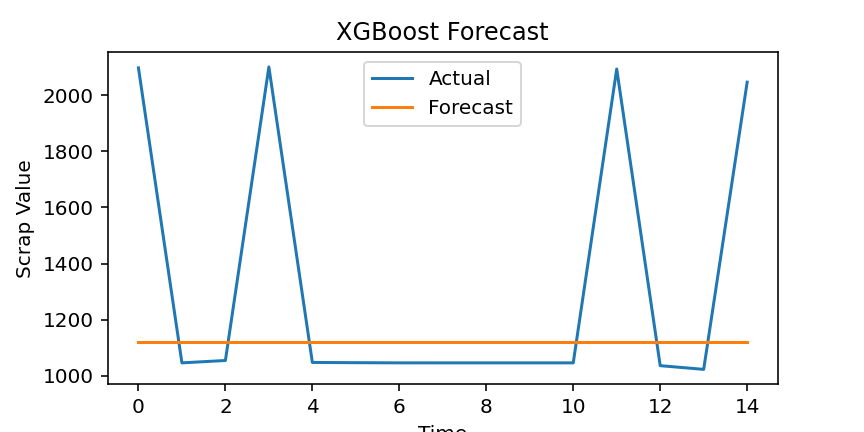
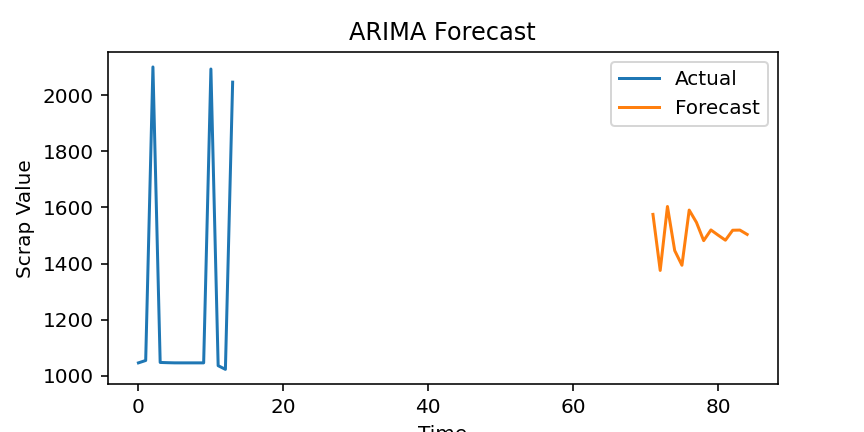

In [21]:
dashboard = pn.Column(
    "# Scrap Value Forecasting Dashboard",
    component_selector,
    xgb_plot_pane,
    arima_plot_pane,
    metrics_pane
)

dashboard.servable()